In [1]:
import xarray as xr
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import os
from utils_ensemble import load_ensemble_tuples

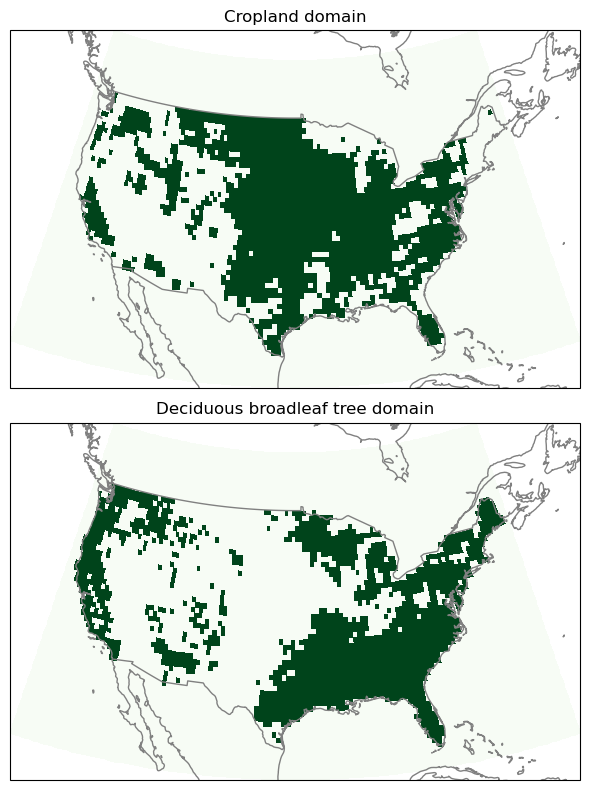

In [2]:
# Plot the domain
fig, axes = plt.subplots(2, 1, figsize = (8, 8), subplot_kw = {'projection': ccrs.LambertConformal()})
i = 0
for which_pft, name in zip(['pft15', 'pft1'], ['Cropland', 'Deciduous broadleaf tree']):
    ax = axes.flat[i]
    ax.add_feature(cfeature.BORDERS, edgecolor='grey')
    ax.add_feature(cfeature.COASTLINE, edgecolor='grey')

    domain_file = os.path.join(os.environ['ZDR'], 'ERW', 'ensemble_surfdata', which_pft, 'domain.lnd.conus_erw_jra.240712.nc')

    hr = xr.open_dataset(domain_file)
    ax.pcolormesh(hr['xc'][0,:], hr['yc'][:,0], hr['mask'], transform = ccrs.PlateCarree(), cmap = 'Greens', vmin = 0, vmax = 1)
    ax.set_title(f'{name} domain')
    hr.close()

    i += 1
plt.tight_layout()

/tmp/ipykernel_1423555/3019904987.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


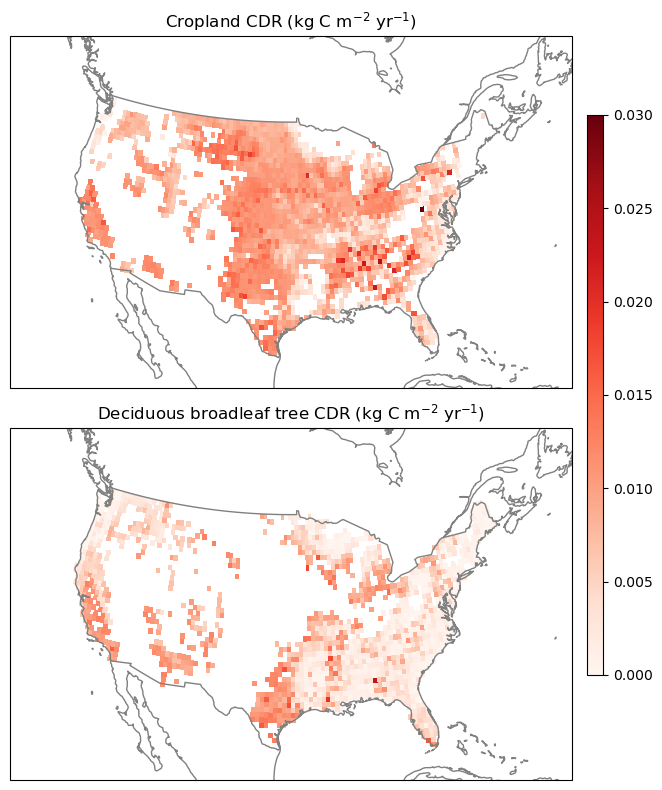

In [3]:
# Plot example CDR
fig, axes = plt.subplots(2, 1, figsize = (8, 8), subplot_kw = {'projection': ccrs.LambertConformal()})
i = 0
for which_pft, name in zip(['pft15', 'pft1'], ['Cropland', 'Deciduous broadleaf tree']):
    ax = axes.flat[i]
    ax.add_feature(cfeature.BORDERS, edgecolor='grey')
    ax.add_feature(cfeature.COASTLINE, edgecolor='grey')

    file = os.path.join(os.environ['ZDR'], 'ERW', 'output', 'UQ', which_pft, 'r_sequestration_diff.nc')

    hr = xr.open_dataset(file)
    cf = ax.pcolormesh(hr['lon'], hr['lat'], hr['r_sequestration_diff'][353, :, :] * 3600 * 24 * 365 / 1000, transform = ccrs.PlateCarree(), cmap = 'Reds', vmin = 0, vmax = 0.03)
    ax.set_title(f'{name} CDR (kg C m$^{{-2}}$ yr$^{{-1}}$)')
    hr.close()

    i += 1
cax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
fig.colorbar(cf, cax = cax, orientation = 'vertical')
plt.tight_layout()

In [4]:
"""temp = ((hr['r_sequestration_diff'].mean(axis = 2).mean(axis = 1) - \
  (hr['n2o_diff'] * 270).mean(axis = 2).mean(axis = 1)) / \
 hr['primary_added_diff'].mean(axis = 2).mean(axis = 1))
temp[1600:2100].plot(figsize = (20, 10))
(np.where(temp[1600:2100] < 0.002)[0] + 1600) + 1

hr['r_sequestration_diff'][1635, :, :].plot()
ensemble_setups = load_ensemble_tuples()
f = ensemble_setups.loc[(ensemble_setups["Grain size (um)"] == 50) & \
                        (ensemble_setups["Rate (kg/m2)"] == 6), :]
temp[ensemble_setups.loc[(ensemble_setups["Grain size (um)"] == 50) & \
                         (ensemble_setups["Rate (kg/m2)"] == 6), :].index].plot()
f['Frequency'].loc[f['Frequency'] == 999] = -1
plt.scatter(
    f['Frequency'],
    temp[ensemble_setups.loc[(ensemble_setups["Grain size (um)"] == 50) & \
                             (ensemble_setups["Rate (kg/m2)"] == 6), :].index],
    c = f['Start year'],
) """

'temp = ((hr[\'r_sequestration_diff\'].mean(axis = 2).mean(axis = 1) -   (hr[\'n2o_diff\'] * 270).mean(axis = 2).mean(axis = 1)) /  hr[\'primary_added_diff\'].mean(axis = 2).mean(axis = 1))\ntemp[1600:2100].plot(figsize = (20, 10))\n(np.where(temp[1600:2100] < 0.002)[0] + 1600) + 1\n\nhr[\'r_sequestration_diff\'][1635, :, :].plot()\nensemble_setups = load_ensemble_tuples()\nf = ensemble_setups.loc[(ensemble_setups["Grain size (um)"] == 50) &                         (ensemble_setups["Rate (kg/m2)"] == 6), :]\ntemp[ensemble_setups.loc[(ensemble_setups["Grain size (um)"] == 50) &                          (ensemble_setups["Rate (kg/m2)"] == 6), :].index].plot()\nf[\'Frequency\'].loc[f[\'Frequency\'] == 999] = -1\nplt.scatter(\n    f[\'Frequency\'],\n    temp[ensemble_setups.loc[(ensemble_setups["Grain size (um)"] == 50) &                              (ensemble_setups["Rate (kg/m2)"] == 6), :].index],\n    c = f[\'Start year\'],\n) '

In [5]:
"""skip = [1635, 1636, 1639, 1640, 1641, 1642, 1644, 1645, 1647, 1648, 1650,
       1651, 1653, 1654, 1656, 1657, 1659, 1660, 1662, 1663, 1664, 1666,
       1667, 1668, 1670, 1671, 1672, 1674, 1675, 1678, 1679, 1682, 1683,
       1686, 1687, 1690, 1691, 1694, 1695, 1698, 1699, 1702, 1703, 1706,
       1707, 1710, 1711, 1714, 1715, 1718, 1722, 1723, 1726, 1727, 1730,
       1731, 1732, 1733, 1734, 1735, 1736, 1738, 1739, 1741, 1742, 1744,
       1745, 1747, 1748, 1750, 1751, 1753, 1754, 1757, 1758, 1761, 1762,
       1765, 1766, 1769, 1770, 1773, 1774, 1777, 1778, 1781, 1782, 1785,
       1786, 1789, 1790, 1793, 1794, 1797, 1798, 1801, 1802, 1805, 1806,
       1813, 1814, 1817, 1818, 1821, 1822, 1823, 1824, 1825, 1826, 1827,
       1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838,
       1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849,
       1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860,
       1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871,
       1872, 1873, 1874, 1875, 1876, 1877, 1878, 1880, 1881, 1882, 1884,
       1885, 1886, 1888, 1889, 1890, 1892, 1893, 1894, 1896, 1897, 1898,
       1900, 1901, 1902, 1904, 1905, 1906, 1908, 1909, 1910, 1912, 1913,
       1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924,
       1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1935, 1936,
       1937, 1939, 1940, 1941, 1943, 1944, 1945, 1947, 1948, 1949, 1951,
       1952, 1953, 1955, 1956, 1957, 1959, 1960, 1961, 1963, 1964, 1965,
       1967, 1968, 1969, 1971, 1972, 1973, 1975, 1976, 1977, 1979, 1980,
       1981, 1983, 1984, 1985, 1987, 1988, 1989, 1991, 1992, 1993, 1995,
       1996, 1997, 1999, 2000, 2001, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2017, 2018, 2020, 2021,
       2023, 2024, 2026, 2027, 2028, 2030, 2031, 2032, 2034, 2035, 2036,
       2038]"""
skip = [] #range(1637, 2276)

In [6]:
tuples = load_ensemble_tuples().iloc[1:]
if len(skip) > 0:
    tuples = tuples.drop(skip, axis = 0)
tuples

,Grain size (um),Rate (kg/m2),Start year,Frequency
1,2,2,2050,1
2,2,2,2049,3
3,2,2,2049,1
4,2,2,2048,3
5,2,2,2048,1
...,...,...,...,...
2271,100,10,2026,1
2272,100,10,2025,999
2273,100,10,2025,9
2274,100,10,2025,3


In [7]:
which_pft = 'pft1'

In [8]:
path_file = os.path.join(os.environ['ZDR'], f'ERW/output/UQ/{which_pft}/r_sequestration_diff.nc')

hr = xr.open_dataset(path_file)

r_sequestration = hr['r_sequestration_diff'].drop_sel(ensemble = skip)
n2o = hr['n2o_diff'].drop_sel(ensemble = skip)
primary_added = hr['primary_added_diff'].drop_sel(ensemble = skip)
CDR = (r_sequestration - n2o * 270) / primary_added

Text(0, 0.5, '')

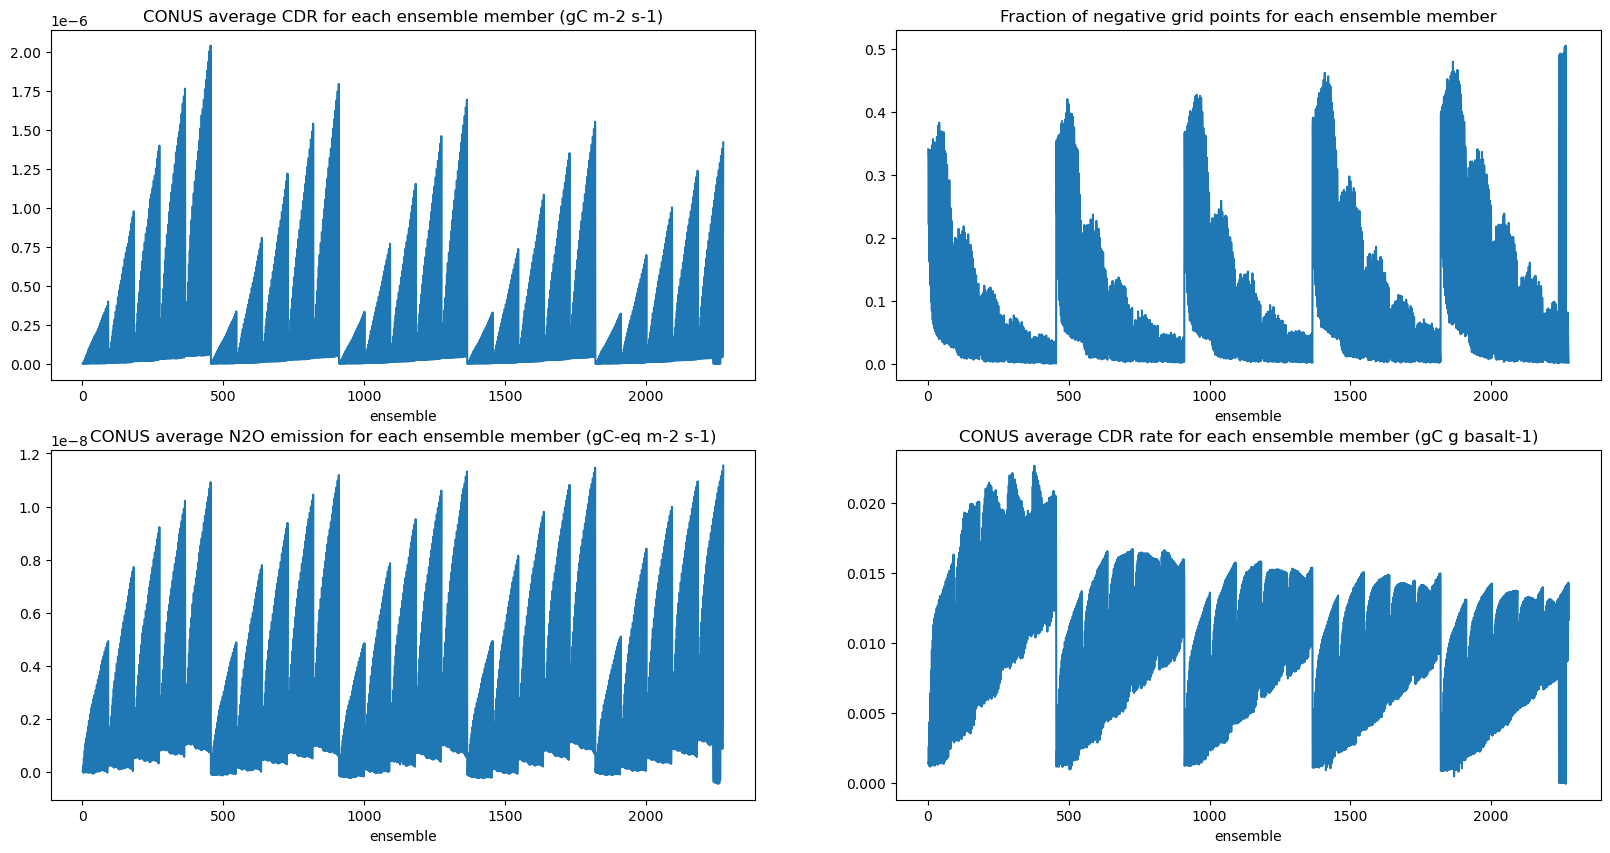

In [9]:
fig, axes = plt.subplots(2, 2, figsize = (20, 10))

ax = axes.flat[0]
r_sequestration.mean(axis = 2).mean(axis = 1).plot(ax=ax)
ax.set_title('CONUS average CDR for each ensemble member (gC m-2 s-1)')
ax.set_ylabel('')

ax = axes.flat[1]
(r_sequestration < 0).where(~np.isnan(hr['r_sequestration_diff'])
).mean(axis = 2).mean(axis = 1).plot(ax=ax)
ax.set_title('Fraction of negative grid points for each ensemble member')
ax.set_ylabel('')

ax = axes.flat[2]
(n2o * 270).mean(axis = 2).mean(axis = 1).plot(ax=ax)
ax.set_title('CONUS average N2O emission for each ensemble member (gC-eq m-2 s-1)')
ax.set_ylabel('')

ax = axes.flat[3]
CDR.mean(axis = 2).mean(axis = 1).plot(ax = ax)
ax.set_title('CONUS average CDR rate for each ensemble member (gC g basalt-1)')
ax.set_ylabel('')

(array([   0,    1,    3,    5,    8,   11,   14,   17,   20,   23,   27,
         31,   35,   39,   43,   47,   51,   55,   59,   63,   67,   71,
        455,  456,  458,  460,  463,  466,  469,  472,  475,  478,  479,
        482,  486,  487,  490,  494,  498,  502,  503,  506,  507,  510,
        514,  518,  522,  530,  534,  910,  911,  913,  915,  918,  921,
        924,  927,  930,  933,  934,  937,  941,  945,  949,  953,  957,
        961,  965,  969,  973,  981,  985,  993, 1365, 1366, 1368, 1370,
       1373, 1376, 1379, 1382, 1385, 1388, 1389, 1392, 1393, 1396, 1397,
       1400, 1401, 1404, 1408, 1412, 1413, 1416, 1420, 1424, 1428, 1432,
       1436, 1440, 1444, 1820, 1821, 1822, 1823, 1825, 1826, 1828, 1829,
       1831, 1832, 1834, 1837, 1840, 1843, 1844, 1847, 1848, 1851, 1852,
       1855, 1856, 1859, 1860, 1863, 1864, 1867, 1868, 1871, 1872, 1875,
       1876, 1879, 1883, 1887, 1891, 1895, 1899, 1903, 1907, 1911, 1912,
       1914, 1916, 1922, 1925, 2240, 2244, 2248, 2

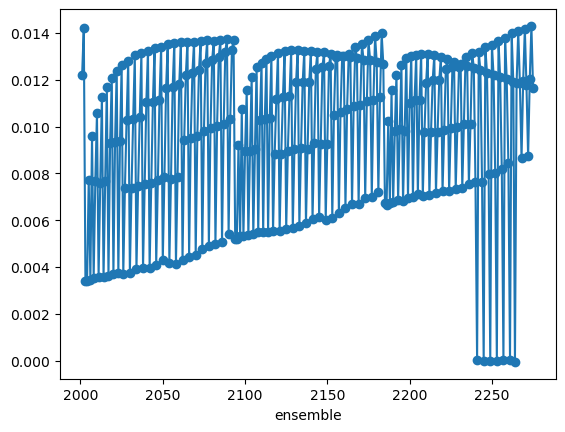

In [10]:
temp = CDR.mean(axis = 2).mean(axis = 1)
temp[2000:].plot(marker = 'o')
#temp[2000:].where(temp[2000:] < 0.002).plot(marker = 'o')
print(np.where(temp < 0.002))

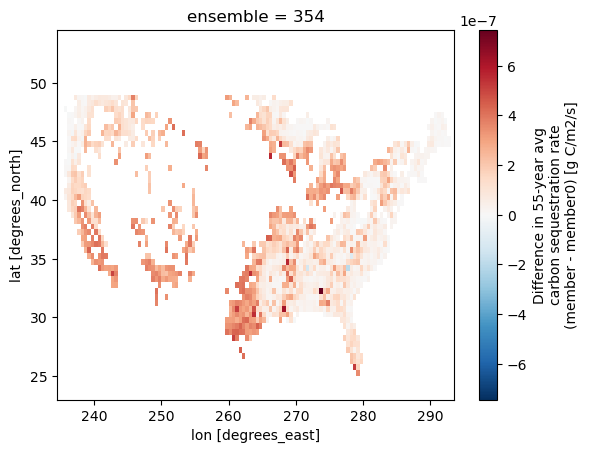

In [11]:
r_sequestration[353, :, :].plot()

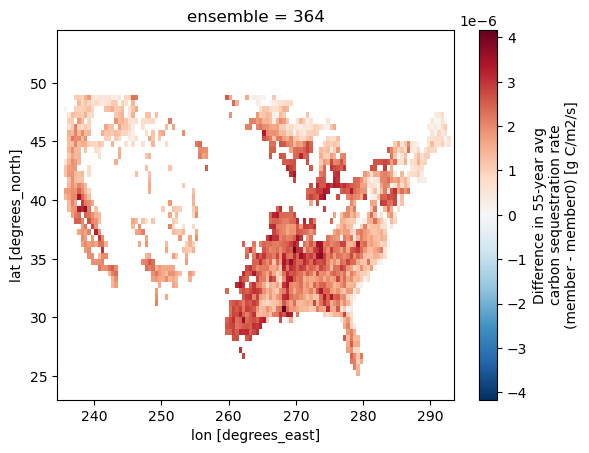

In [12]:
r_sequestration[363, :, :].plot()

/tmp/ipykernel_1423555/2245631893.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


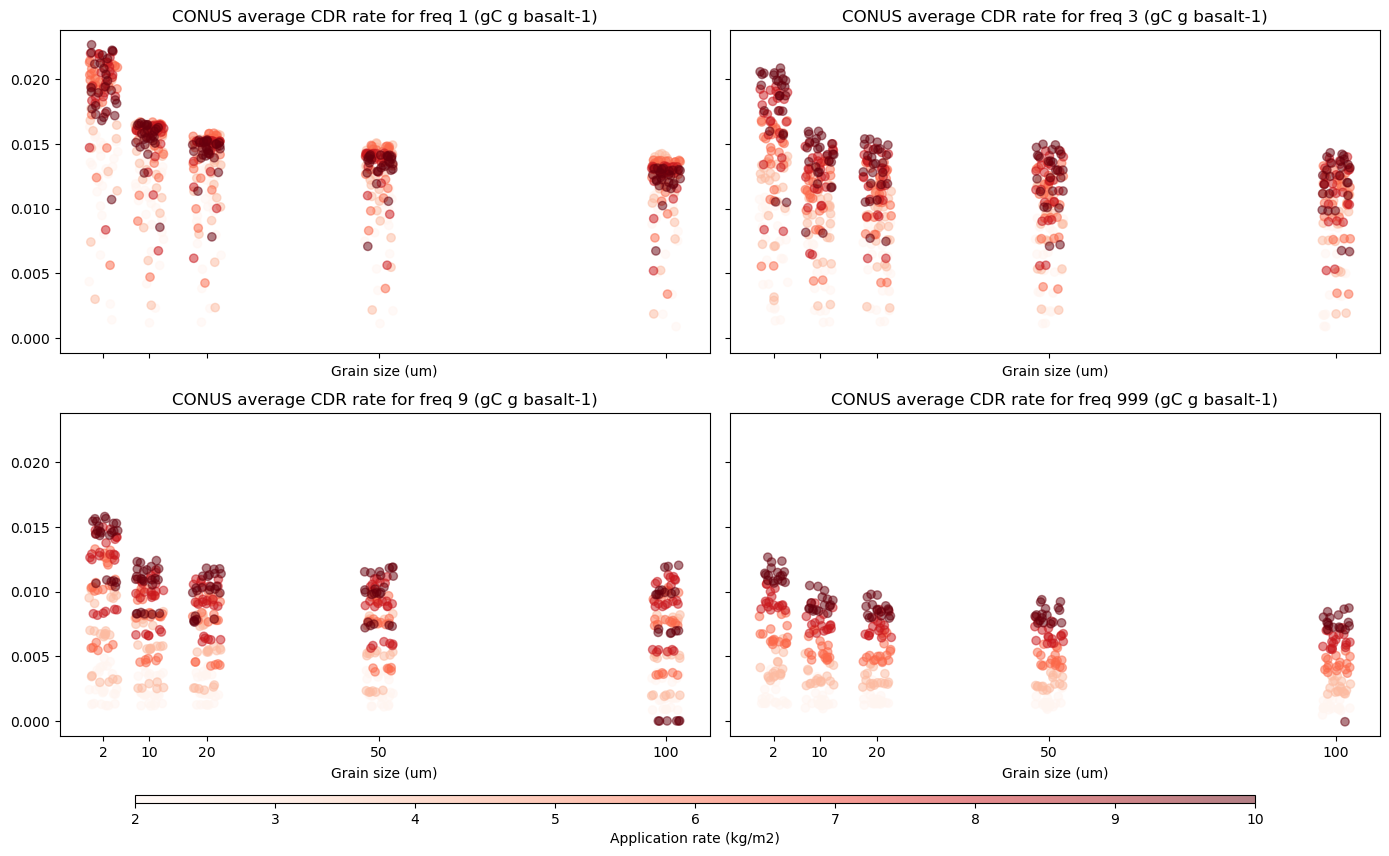

In [13]:
fig, axes = plt.subplots(2, 2, figsize = (14, 8), sharex = True, sharey = True)

temp = CDR.mean(axis = 2).mean(axis = 1).values

for i, freq in enumerate([1,3,9,999]):
    ax = axes.flat[i]

    gra = tuples.loc[tuples['Frequency'] == freq, 'Grain size (um)']
    rate = tuples.loc[tuples['Frequency'] == freq, 'Rate (kg/m2)']
    temp_temp = temp[tuples['Frequency'] == freq]

    x_jitter = np.random.rand(len(gra)) * 5 - 2.5
    cf = ax.scatter(gra + x_jitter, temp_temp, c = rate, alpha = 0.5, cmap = 'Reds')

    ax.set_title(f'CONUS average CDR rate for freq {freq} (gC g basalt-1)')
    ax.set_ylabel('')
    ax.set_xticks([2, 10, 20, 50, 100])
    ax.set_xlabel('Grain size (um)')
cax = fig.add_subplot([0.1, -0.01, 0.8, 0.01])
plt.colorbar(cf, cax = cax, orientation = 'horizontal', label = 'Application rate (kg/m2)')
plt.tight_layout()

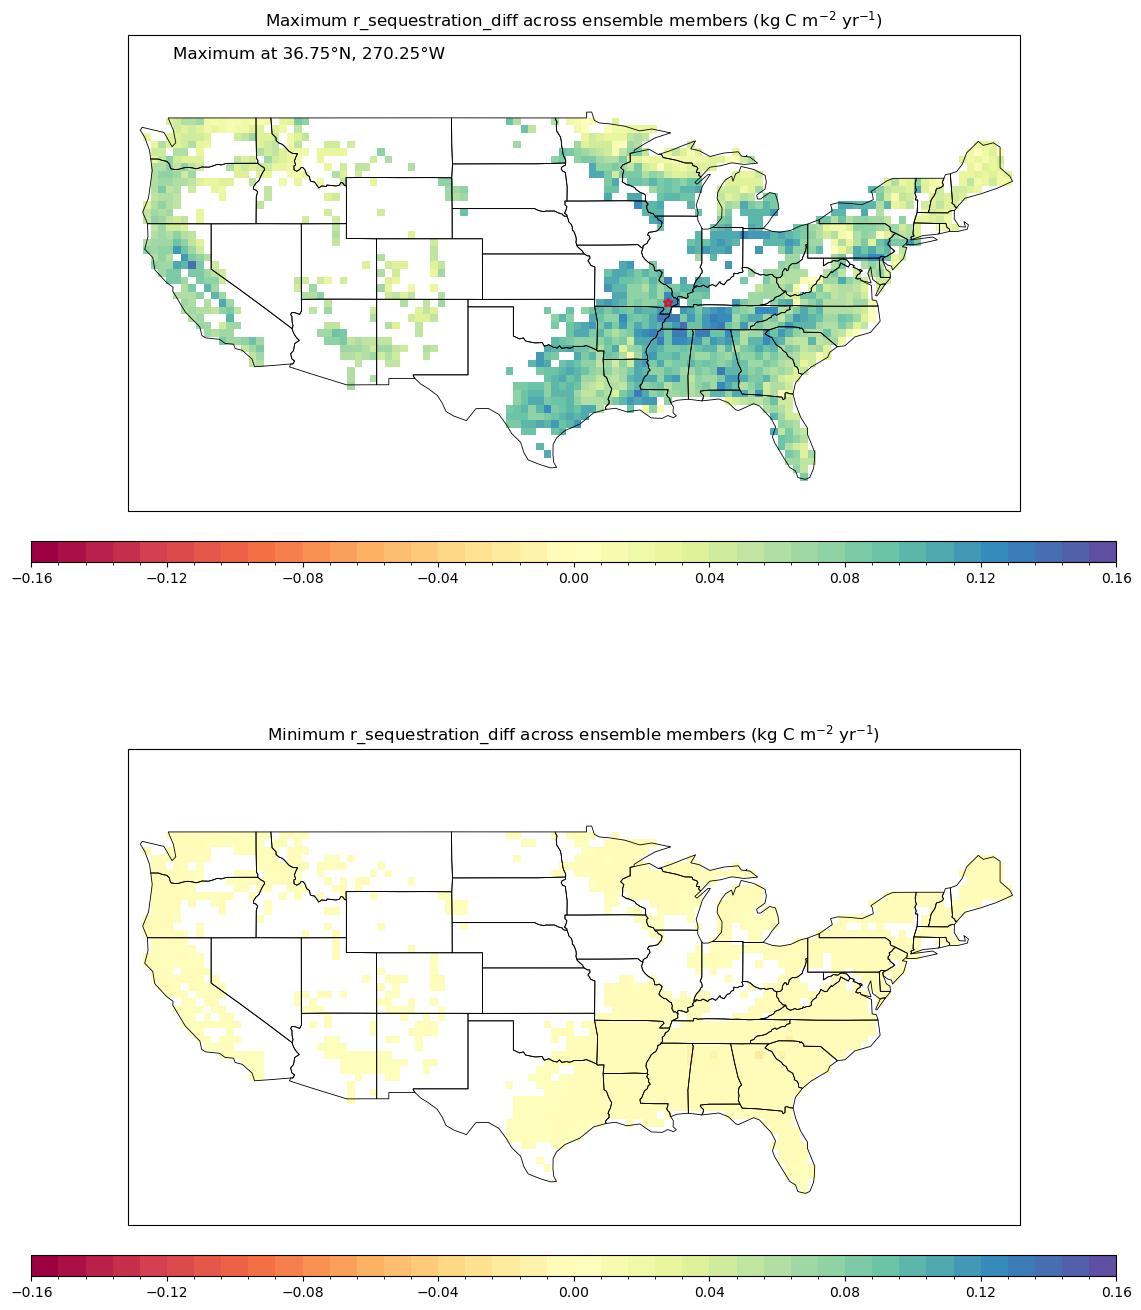

In [14]:
# Plot the spatial map of maximum and minimum r_sequestration_diff
# over all the ensemble members

levels = np.linspace(-0.16, 0.16, 41)
norm = BoundaryNorm(boundaries=levels, ncolors=256, clip=True)

fig, axes = plt.subplots(2, 1, figsize=(20, 17), subplot_kw={'projection': ccrs.PlateCarree()})

for ax in axes:
    ax.add_feature(
        cfeature.STATES.with_scale('110m'),
        edgecolor='black',
        linewidth=0.6
    )

ax = axes.flat[0]

spatial_max = r_sequestration.max(dim='ensemble') * 3600 * 24 * 365 / 1000
cf = ax.pcolormesh(hr['lon'], hr['lat'], spatial_max, cmap='Spectral', norm=norm)
ax.set_title('Maximum r_sequestration_diff across ensemble members (kg C m$^{{-2}}$ yr$^{{-1}}$)')
plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, aspect=50, shrink=0.7)

# Find where the largest sequstration rate occurs
flat  = spatial_max.stack(points=('lat', 'lon'))  # points → 63×118 = 7 434 elements
imax  = flat.argmax('points')            # integer index of the single maximum

lat_max = flat['lat'].isel(points=imax).item()   # float
lon_max = flat['lon'].isel(points=imax).item()   # float

ax.scatter(lon_max, lat_max, color='r', s=50, marker='*', fc = 'none', transform=ccrs.PlateCarree())
ax.text(0.05, 0.95,
        f'Maximum at {lat_max:.2f}°N, {lon_max:.2f}°W',
        color='black', fontsize=12, transform=ax.transAxes)


ax = axes.flat[1]
spatial_min = r_sequestration.min(dim='ensemble') * 3600 * 24 * 365 / 1000
cf = ax.pcolormesh(hr['lon'], hr['lat'], spatial_min, 
                   cmap='Spectral', norm=norm)
ax.set_title('Minimum r_sequestration_diff across ensemble members (kg C m$^{{-2}}$ yr$^{{-1}}$)')
plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, aspect=50, shrink=0.7)

In [15]:
best_spatial_location = r_sequestration.sel(lat=lat_max, lon=lon_max).values

best_tuple = tuples.iloc[best_spatial_location.argmax()]

print('Best tuple for sequestration rate at maximum location:')
print(best_tuple)

Best tuple for sequestration rate at maximum location:
Grain size (um)       2
Rate (kg/m2)         10
Start year         2025
Frequency             1
Name: 455, dtype: int64


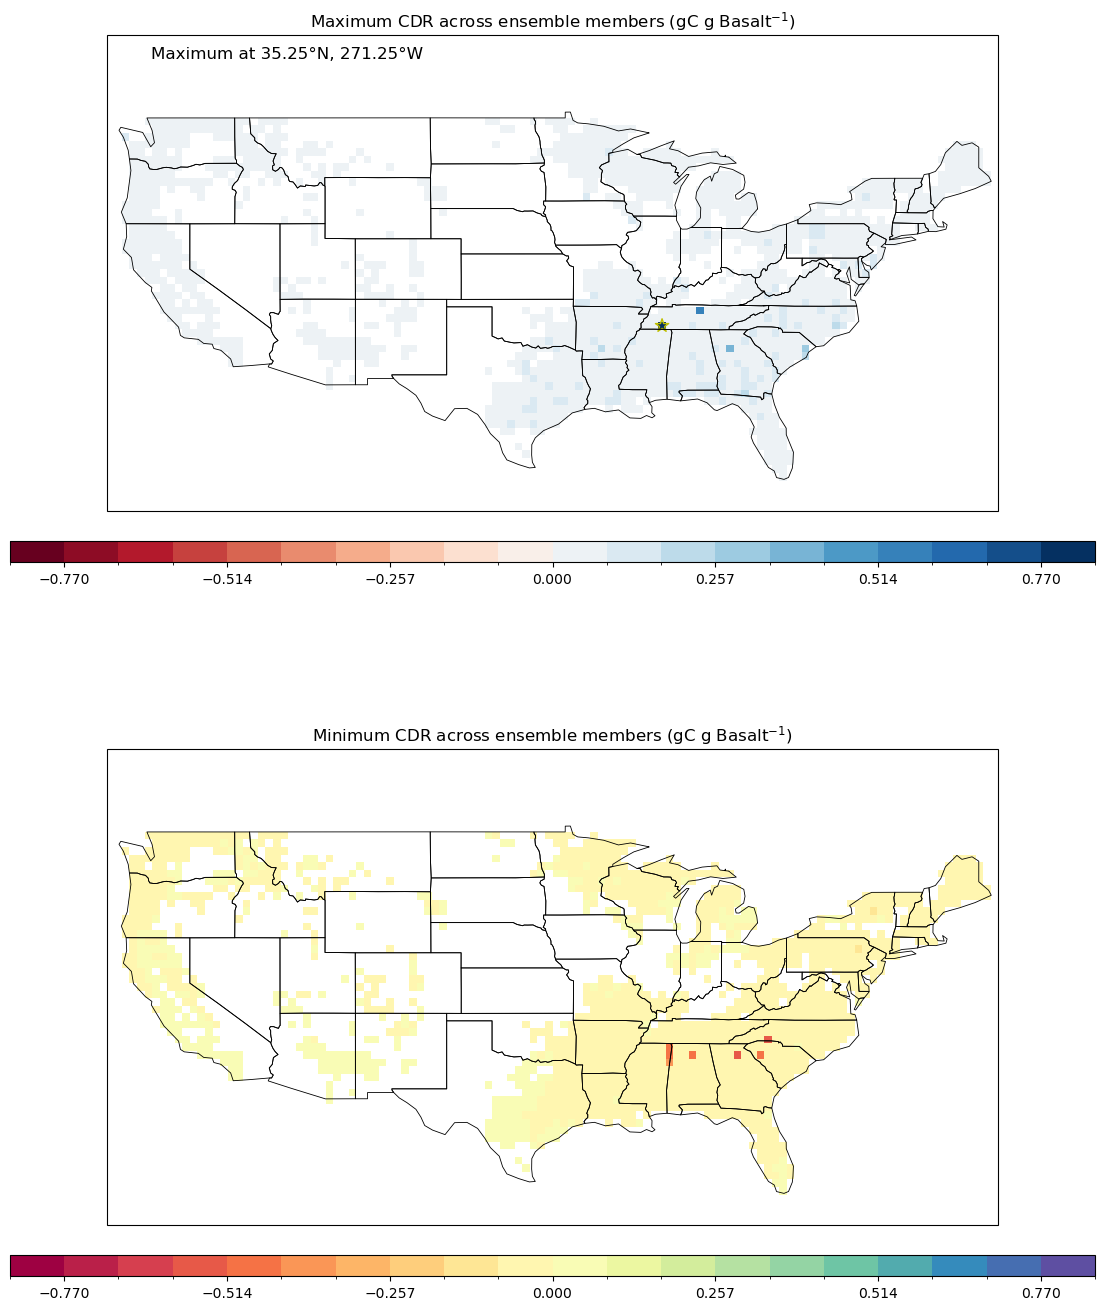

In [16]:
# Plot the spatial map of maximum and minimum normalized net CDR
# over all the ensemble members
# 
# (r_sequestion_diff - n2o_diff * 270) / primary_added_diff

#levels = np.array([-0.9, -0.8, -0.6, -0.4, -0.2, -0.1, -0.01, -0.001, 0, 
#                  0.001, 0.01, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9])
levels = np.linspace(-0.856, 0.856, 21)
norm = BoundaryNorm(boundaries=levels, ncolors=256, clip=True)

fig, axes = plt.subplots(2, 1, figsize=(20, 17), subplot_kw={'projection': ccrs.PlateCarree()})

for ax in axes.flat:
    ax.add_feature(
        cfeature.STATES.with_scale('110m'),
        edgecolor='black',
        linewidth=0.6
    )

ax = axes.flat[0]

spatial_max = CDR.max(dim='ensemble')
cf = ax.pcolormesh(hr['lon'], hr['lat'], spatial_max, cmap='RdBu', norm=norm)
ax.set_title('Maximum CDR across ensemble members (gC g Basalt$^{-1}$)')
plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, aspect=50, shrink=0.7)

# Find where the largest sequstration rate occurs
flat  = spatial_max.stack(points=('lat', 'lon'))  # points → 63×118 = 7 434 elements
imax  = flat.argmax('points')            # integer index of the single maximum

lat_max = flat['lat'].isel(points=imax).item()   # float
lon_max = flat['lon'].isel(points=imax).item()   # float

ax.scatter(lon_max, lat_max, color='y', s=100, marker='*', fc = 'none', transform=ccrs.PlateCarree())
ax.text(0.05, 0.95,
        f'Maximum at {lat_max:.2f}°N, {lon_max:.2f}°W',
        color='black', fontsize=12, transform=ax.transAxes)

ax = axes.flat[1]
cf = ax.pcolormesh(hr['lon'], hr['lat'], CDR.min(dim='ensemble'), 
                   cmap='Spectral', norm=norm)
ax.set_title('Minimum CDR across ensemble members (gC g Basalt$^{-1}$)')
plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, aspect=50, shrink=0.7)

In [17]:
best_spatial_location = CDR.sel(lat=lat_max, lon=lon_max).values

best_tuple = tuples.iloc[best_spatial_location.argmax()]

print('Best tuple for sequestration rate at maximum location:')
print(best_tuple)

Best tuple for sequestration rate at maximum location:
Grain size (um)      10
Rate (kg/m2)          2
Start year         2025
Frequency           999
Name: 543, dtype: int64


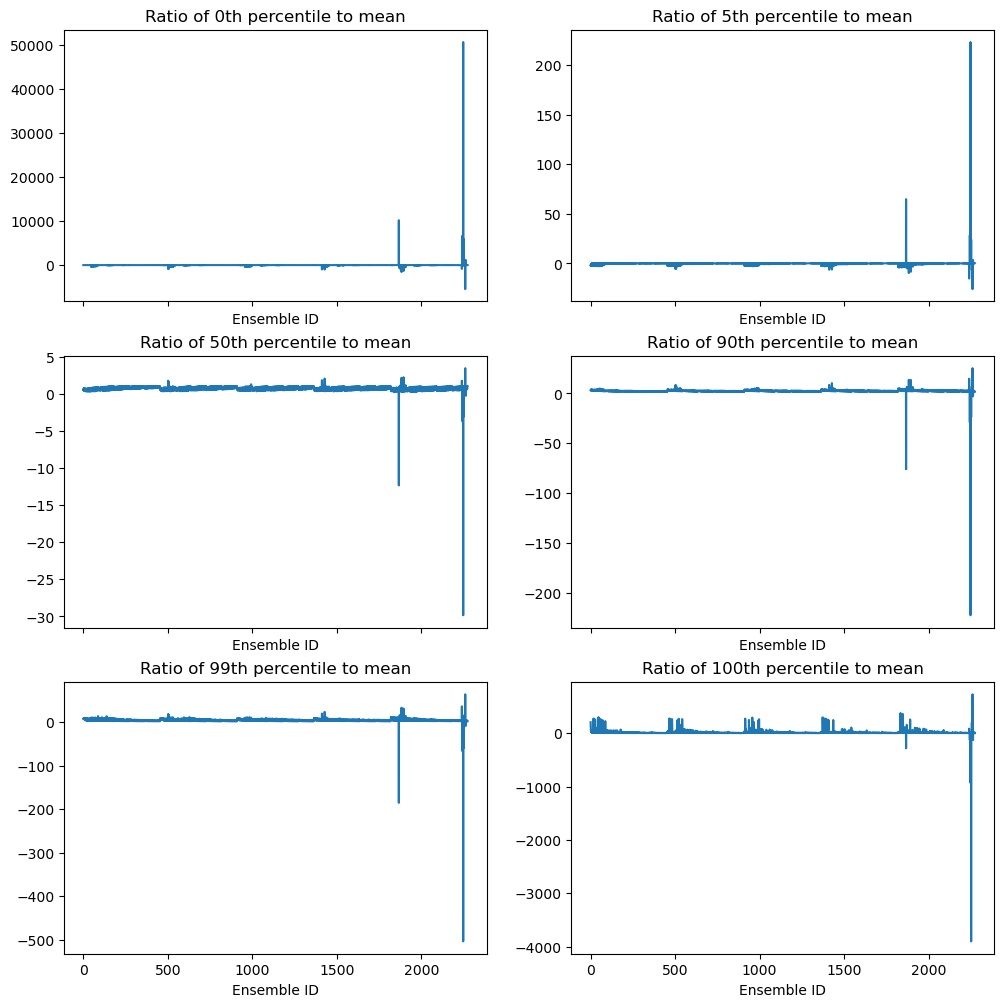

In [18]:
# For each ensemble member, ratio of min, p05, p50, p90, p99, max to mean
fig, axes = plt.subplots(3, 2, figsize = (12, 12), sharex = True, sharey = False)

temp = CDR.values.reshape(CDR.shape[0], -1)

for i, pct in enumerate([0, 5, 50, 90, 99, 100]):
    ratio = np.nanpercentile(temp, pct, axis = 1) / np.nanmean(temp, axis = 1)

    ax = axes.flat[i]
    ax.plot(ratio)

    ax.set_title(f'Ratio of {pct}th percentile to mean')
    ax.set_xlabel('Ensemble ID')